/tmp/ipython-input-772619908.py:174: RuntimeWarning: overflow encountered in exp
  f1 = 1.0 / (np.exp((E1_grid - mu) / (K_B * T)) + 1.0)
/tmp/ipython-input-772619908.py:175: RuntimeWarning: overflow encountered in exp
  f2 = 1.0 / (np.exp((E2_grid - mu) / (K_B * T)) + 1.0)


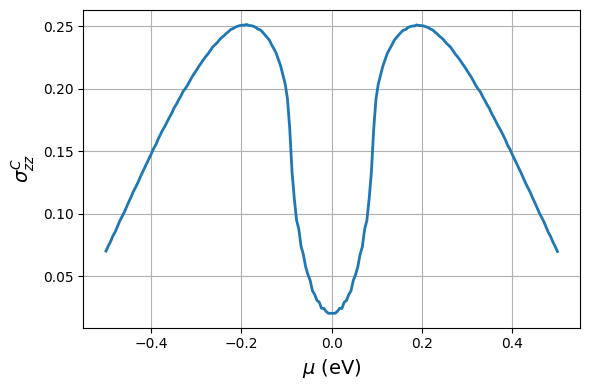

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh

# ---------------- Pauli matrices ----------------
sigma_0 = np.array([[1, 0], [0, 1]], dtype=complex)
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)

# ---------------- Model parameters ----------------
t = -0.05          # eV
m = 0.15           # eV-like parameter
k0 = np.pi / 2     # dimensionless (radians)
gamma = 0.0        # eV

# ---------------- k-space grid ----------------
Nx = Ny = Nz = 40
kx = np.linspace(-np.pi, np.pi, Nx)
ky = np.linspace(-np.pi, np.pi, Ny)
kz = np.linspace(-np.pi, np.pi, Nz)

# ---------------- Build Hamiltonian  ----------------
H = np.zeros((2, 2, Nx, Ny, Nz), dtype=complex)
for ix, kxi in enumerate(kx):
    for iy, kyj in enumerate(ky):
        for iz, kzk in enumerate(kz):
            term1 = (m * (np.cos(kyj) + np.cos(kzk) - 2.0)
                     + 2.0 * t * (np.cos(kxi) - np.cos(k0))) * sigma_x
            term2 = -2.0 * t * np.sin(kyj) * sigma_y
            term3 = -2.0 * t * np.sin(kzk) * sigma_z
            termT = gamma * (np.cos(kxi) - np.cos(k0)) * sigma_0
            H[:, :, ix, iy, iz] = term1 + term2 + term3 + termT

# ---------------- Numerical derivatives dH/dkx, dH/dky, dH/dkz ----------------
H_kx = np.zeros_like(H)
H_ky = np.zeros_like(H)
H_kz = np.zeros_like(H)

# d/dkx
for ix in range(Nx):
    for iy in range(Ny):
        for iz in range(Nz):
            if 0 < ix < Nx - 1:
                dkx = kx[ix + 1] - kx[ix - 1]
                H_kx[:, :, ix, iy, iz] = (H[:, :, ix + 1, iy, iz] - H[:, :, ix - 1, iy, iz]) / dkx
            elif ix == 0:
                dkx = kx[1] - kx[0]
                H_kx[:, :, ix, iy, iz] = (H[:, :, ix + 1, iy, iz] - H[:, :, ix, iy, iz]) / dkx
            else:
                dkx = kx[-1] - kx[-2]
                H_kx[:, :, ix, iy, iz] = (H[:, :, ix, iy, iz] - H[:, :, ix - 1, iy, iz]) / dkx

# d/dky
for ix in range(Nx):
    for iy in range(Ny):
        for iz in range(Nz):
            if 0 < iy < Ny - 1:
                dky = ky[iy + 1] - ky[iy - 1]
                H_ky[:, :, ix, iy, iz] = (H[:, :, ix, iy + 1, iz] - H[:, :, ix, iy - 1, iz]) / dky
            elif iy == 0:
                dky = ky[1] - ky[0]
                H_ky[:, :, ix, iy, iz] = (H[:, :, ix, iy + 1, iz] - H[:, :, ix, iy, iz]) / dky
            else:
                dky = ky[-1] - ky[-2]
                H_ky[:, :, ix, iy, iz] = (H[:, :, ix, iy, iz] - H[:, :, ix, iy - 1, iz]) / dky

# d/dkz
for ix in range(Nx):
    for iy in range(Ny):
        for iz in range(Nz):
            if 0 < iz < Nz - 1:
                dkz = kz[iz + 1] - kz[iz - 1]
                H_kz[:, :, ix, iy, iz] = (H[:, :, ix, iy, iz + 1] - H[:, :, ix, iy, iz - 1]) / dkz
            elif iz == 0:
                dkz = kz[1] - kz[0]
                H_kz[:, :, ix, iy, iz] = (H[:, :, ix, iy, iz + 1] - H[:, :, ix, iy, iz]) / dkz
            else:
                dkz = kz[-1] - kz[-2]
                H_kz[:, :, ix, iy, iz] = (H[:, :, ix, iy, iz] - H[:, :, ix, iy, iz - 1]) / dkz

# ---------------- Arrays for Z_zz-like components ----------------
zzz12 = np.zeros((Nx, Ny, Nz))
zzz21 = np.zeros((Nx, Ny, Nz))
zzz31 = np.zeros((Nx, Ny, Nz))

E1_grid = np.zeros((Nx, Ny, Nz))
E2_grid = np.zeros((Nx, Ny, Nz))

epsilon = 1e-4

use_hbar_velocity = False

# hbar in eV*s
hbar_SI = 1.054571817e-34
eV_to_J = 1.602176634e-19
hbar_eVs = hbar_SI / eV_to_J

for ix in range(Nx):
    for iy in range(Ny):
        for iz in range(Nz):
            H_curr = H[:, :, ix, iy, iz]

            if use_hbar_velocity:
                Hkx_curr = H_kx[:, :, ix, iy, iz] / hbar_eVs
                Hky_curr = H_ky[:, :, ix, iy, iz] / hbar_eVs
                Hkz_curr = H_kz[:, :, ix, iy, iz] / hbar_eVs
            else:
                Hkx_curr = H_kx[:, :, ix, iy, iz]
                Hky_curr = H_ky[:, :, ix, iy, iz]
                Hkz_curr = H_kz[:, :, ix, iy, iz]

            E, V = eigh(H_curr)
            E1 = E[0].real
            E2 = E[1].real
            v1 = V[:, 0]
            v2 = V[:, 1]

            # matrix elements of Pauli matrices between bands
            sigma12z = np.vdot(v1, sigma_z @ v2)
            sigma21z = np.vdot(v2, sigma_z @ v1)
            sigma12x = np.vdot(v1, sigma_x @ v2)
            sigma21x = np.vdot(v2, sigma_x @ v1)

            # velocity matrix elements (derivative of H)
            v_12z = np.vdot(v1, Hkz_curr @ v2)
            v_21z = np.vdot(v2, Hkz_curr @ v1)
            v_12x = np.vdot(v1, Hkx_curr @ v2)
            v_21x = np.vdot(v2, Hkx_curr @ v1)

            den1 = 1j * (E1 - E2 + epsilon)
            den2 = 1j * (E2 - E1 + epsilon)

            if abs(E1 - E2) > 1e-12:

                num1 = 2.0 * v_12z * sigma21z
                num2 = 2.0 * v_21z * sigma12z

                num3 = 2.0 * v_12x * sigma21x

                z_z12 = num1 / den1
                z_z21 = num2 / den2
                z_z31 = num3 / den1
            else:
                z_z12 = 0.0
                z_z21 = 0.0
                z_z31 = 0.0

            zzz12[ix, iy, iz] = np.imag(z_z12)
            zzz21[ix, iy, iz] = np.imag(z_z21)
            zzz31[ix, iy, iz] = np.imag(z_z31)

            E1_grid[ix, iy, iz] = E1
            E2_grid[ix, iy, iz] = E2

# ---------------- Conductivity: symmetric sigma_zz ----------------
N_mu = 200
mu_vals = np.linspace(-0.5, 0.5, N_mu)   # eV

K_B = 8.617333262e-5   # eV/K
T = 1.0                # K

dkx = kx[1] - kx[0]
dky = ky[1] - ky[0]
dkz = kz[1] - kz[0]
dk3 = dkx * dky * dkz

# include BZ normalization
bz_norm = 1.0 / (2.0 * np.pi)**3

sigma_zz_numeric = np.zeros(N_mu)

for idx, mu in enumerate(mu_vals):
    f1 = 1.0 / (np.exp((E1_grid - mu) / (K_B * T)) + 1.0)
    f2 = 1.0 / (np.exp((E2_grid - mu) / (K_B * T)) + 1.0)

    sig1_s = np.sum((zzz12 + zzz31) * f1) * dk3 * bz_norm
    sig2_s = np.sum((zzz21 + zzz31) * f2) * dk3 * bz_norm

    sigma_zz_numeric[idx] = -np.pi * (sig1_s + sig2_s)

# ---------------- Plot numeric sigma_zz (model units) ----------------
plt.figure(figsize=(6, 4))
plt.plot(mu_vals, sigma_zz_numeric, linewidth=2)
plt.xlabel(r'$\mu$ (eV)', fontsize=14)
plt.ylabel(r'$\sigma^{C}_{zz}$', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()
